In [15]:
import pandas as pd
import numpy as np

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [17]:
from sklearn.ensemble import RandomForestRegressor

In [18]:
from xgboost import XGBRegressor

In [19]:
from lightgbm import LGBMRegressor

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv(
    "../data/processed/secondary_sales_cleaned.csv"
)

print(df.head())

        id date_listed      locality        region     tier       lat  \
0  S000001  2024-11-23  Breach Candy  South Mumbai   luxury  18.96953   
1  S000002  2023-07-05  Breach Candy  South Mumbai   luxury  18.97230   
2  S000003  2022-01-22    Malad East       Western      mid  19.18986   
3  S000004  2020-11-18   Mulund West       Central      mid  19.15854   
4  S000005  2025-01-11       Matunga       Central  premium  19.02358   

        lon property_type  bedrooms  carpet_area_sqft  ...  price_usd  \
0  72.81853          3BHK         3              1048  ...     740322   
1  72.81017          2BHK         2               729  ...     481523   
2  72.85940          2BHK         2               705  ...     125398   
3  72.93798          1BHK         1               424  ...      65036   
4  72.85690          1BHK         1               392  ...     140553   

   home_loan_rate_at_listing  listing_year  listing_month  property_age  \
0                       9.20          2024     

In [22]:
# Removed investment_score to avoid target leakage

features = [
    'region',
    'tier',
    'property_type',
    'bedrooms',
    'carpet_area_sqft',
    'built_up_area_sqft',
    'floor',
    'total_floors',
    'property_age',
    'furnishing',
    'parking',
    'balconies',
    'builder_tier',
    'metro_distance_min',
    'to_bkc_km',
    'to_nariman_point_km',
    'luxury_score',
    'connectivity_score'
]

target = 'price_inr'


X = df[features]
y = df[target]

In [23]:
categorical_cols = X.select_dtypes(
    include=['object', 'string']
).columns

print("Categorical Columns:")
print(categorical_cols)

label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = le

print("Encoding Complete")

Categorical Columns:
Index(['region', 'tier', 'property_type', 'furnishing', 'parking',
       'builder_tier'],
      dtype='str')
Encoding Complete


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
def evaluate_model(name, model):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    print(f"\n{name}")
    print("-" * 40)

    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R²   : {r2:.4f}")

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }


In [26]:
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    "Random Forest",
    rf_model
)


Random Forest
----------------------------------------
MAE  : 3,814,688.11
RMSE : 7,169,681.09
R²   : 0.9328


In [27]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=2,
    random_state=42
)

xgb_model.fit(X_train, y_train)

evaluate_model("Tuned XGBoost", xgb_model)


Tuned XGBoost
----------------------------------------
MAE  : 3,678,283.75
RMSE : 6,832,922.04
R²   : 0.9390


{'Model': 'Tuned XGBoost',
 'MAE': 3678283.75,
 'RMSE': np.float64(6832922.044984269),
 'R2': 0.9389615654945374}

In [28]:
lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=2,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

evaluate_model("Tuned LightGBM", lgbm_model)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1472
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 18
[LightGBM] [Info] Start training from score 23162317.543600

Tuned LightGBM
----------------------------------------
MAE  : 3,740,661.18
RMSE : 6,839,256.64
R²   : 0.9388


{'Model': 'Tuned LightGBM',
 'MAE': 3740661.183795126,
 'RMSE': np.float64(6839256.640003243),
 'R2': 0.9388483409956967}

In [29]:
results_df = pd.DataFrame([
    rf_results,
    xgb_results,
    lgbm_results
])

print("\nMODEL COMPARISON")
print("=" * 50)

print(results_df)

NameError: name 'xgb_results' is not defined

# Overfitting Check 

In [30]:
models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

for name, model in models.items():

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"\n{name}")
    print("=" * 50)

    print(f"Training R² : {train_r2:.4f}")
    print(f"Testing R²  : {test_r2:.4f}")

    diff = train_r2 - test_r2

    print(f"Difference  : {diff:.4f}")

    if diff > 0.05:
        print("⚠️ Possible Overfitting Detected")

    else:
        print("✅ Model Generalizes Well")


Random Forest
Training R² : 0.9906
Testing R²  : 0.9328
Difference  : 0.0578
⚠️ Possible Overfitting Detected

XGBoost
Training R² : 0.9559
Testing R²  : 0.9390
Difference  : 0.0169
✅ Model Generalizes Well

LightGBM
Training R² : 0.9509
Testing R²  : 0.9388
Difference  : 0.0121
✅ Model Generalizes Well


# Cross validation

In [31]:
cv_scores = cross_val_score(
    lgbm_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", cv_scores)

print("Average CV Score:", cv_scores.mean())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1472
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 18
[LightGBM] [Info] Start training from score 23119287.271000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002184 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1471
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 18
[LightGBM] [Info] Start training from score 23167531.670200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1471
[LightGBM] [Info] Number of data points in

# Feature Importance

In [32]:
importance_df = pd.DataFrame({

    'Feature': X.columns,

    'Importance': lgbm_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                Feature  Importance
4      carpet_area_sqft        1177
5    built_up_area_sqft         673
14            to_bkc_km         635
15  to_nariman_point_km         614
13   metro_distance_min         481
12         builder_tier         444
1                  tier         365
6                 floor         343
16         luxury_score         343
8          property_age         296
0                region         283
9            furnishing         109
17   connectivity_score          93
2         property_type          46
7          total_floors          33
3              bedrooms          27
11            balconies          20
10              parking          18


# Plotting

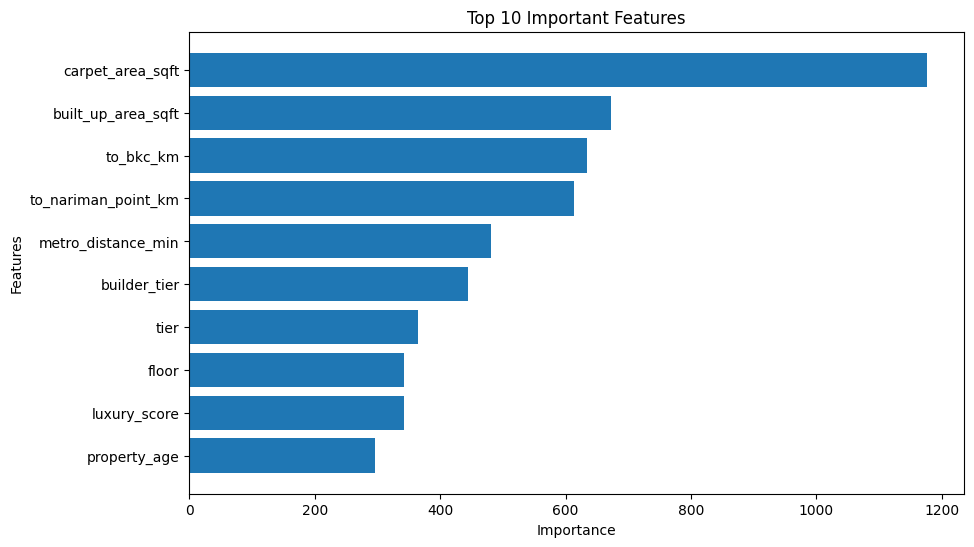

In [33]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Features")

plt.title("Top 10 Important Features")

plt.show()

# SHAP EXPLAINABILITY

In [34]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import shap

# Creating Explainer
We founf LightGBM to be the best model out of all three 


In [36]:
explainer = shap.TreeExplainer(lgbm_model)

shap_values = explainer.shap_values(X_test)

# Shap summary plot
This tells:

which features push prices higher
which features reduce prices
global model behavior

This is REAL explainable AI.

In [37]:
import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.savefig(
    "../reports/shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

In [38]:
import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../reports/shap_bar.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()

In [39]:
import joblib

joblib.dump(lgbm_model, "../models/final_lightgbm_model.pkl")
joblib.dump(label_encoders, "../models/label_encoders.pkl")
joblib.dump(xgb_model, "../models/final_xgboost_model.pkl")
joblib.dump(rf_model, "../models/final_random_forest_model.pkl")

print("✅ All models and preprocessing files saved successfully!")

✅ All models and preprocessing files saved successfully!


In [40]:
print(label_encoders.keys())

dict_keys(['region', 'tier', 'property_type', 'furnishing', 'parking', 'builder_tier'])
